# Day 08. Exercise 00
# Binary classifier. Logistic regression

## 0. Imports

In [64]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

## 1. Preprocessing

In [65]:
file = pd.read_csv('../data/checker_timestamp.csv')

df = pd.DataFrame({
    'date': pd.to_datetime(file['timestamp']).dt.date,
    'am':  pd.to_datetime(file['timestamp']).dt.hour < 12,
    'pm':  pd.to_datetime(file['timestamp']).dt.hour >= 12,
    'target': pd.to_datetime(file['timestamp']).dt.day_of_week.isin([5,6])
})

In [66]:
df = df.groupby(['date','target']).agg({'am':'sum', 'pm':'sum'}).reset_index()
df['target'] = ['weekend' if i else 'work' for i in df['target']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    35 non-null     object
 1   target  35 non-null     object
 2   am      35 non-null     int64 
 3   pm      35 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 1.2+ KB


## 2. Exploratory analysis

<Axes: xlabel='am', ylabel='pm'>

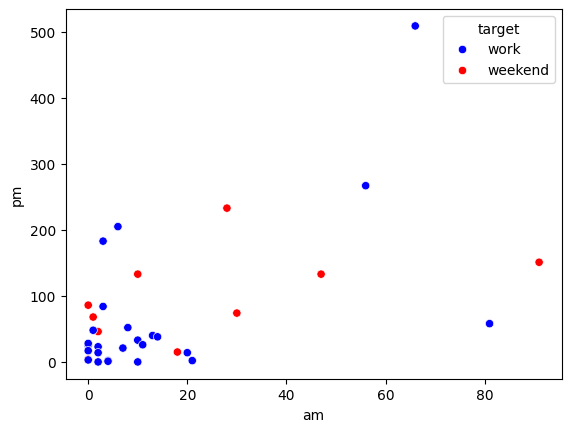

In [67]:
sns.scatterplot(x='am', y='pm', data=df, hue='target', palette={'weekend': "red",'work': "blue"})

>***Как вы думаете, легко ли будет классифицировать дни по этим двум признакам, взглянув на график?***
>
> Ответ: **Нет, это не легко**

## 3. Logistic regression

In [68]:
x = df[['am','pm']]
y = df['target']

In [69]:
model = LogisticRegression(random_state=21, fit_intercept=False).fit(x, y)
y_predict = model.predict(x)
df['predict'] = y_predict
df.to_csv('../data/am_pm.csv', index=False)

<Axes: xlabel='am', ylabel='pm'>

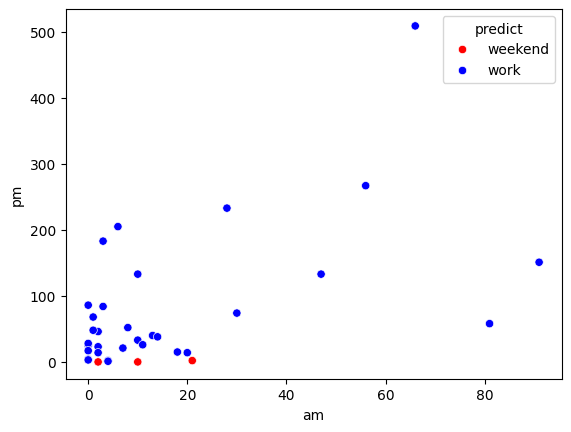

In [70]:
sns.scatterplot(x='am', y='pm', data=df, hue='predict', palette={'weekend': "red",'work': "blue"})

>***Глядя на график, как вы думаете, дает ли он хорошие прогнозы?***
>
> Ответ: **Нет, получилось не очень**

## 4. Evaluation

In [ ]:
print(f'Accuracy Score: {accuracy_score(y, y_predict)}')

Accuracy Score: 0.6285714285714286


In [ ]:
most = [df['target'].mode()[0]]*len(df)
print(f'Accuracy Score with most popular class: {accuracy_score(y, most)}')

Accuracy Score with most popular class: 0.7142857142857143


> ***Сравнивая точности, считаете ли вы, что классификатор дал хорошие прогнозы?***
>
>Точность наивного случая - 71% - (просто большинство) выше, чем предсказанные моделью прогнозы 62%
>
> Ответ: **Нет, модель неточная**